In [7]:
import pandas as pd
import matplotlib.pyplot as plt #import plotting package
#render plotting automatically
%matplotlib inline
import matplotlib as mpl #additional plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high resolution figures
mpl.rcParams['font.size'] = 4 #font size for figures
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_auc_score, roc_curve

In [8]:
from sklearn.model_selection import KFold
n_folds = 4
k_folds = KFold(n_splits=n_folds, shuffle=False)

In [2]:
df = pd.read_csv('df_cleaned.csv')

In [4]:
features_response = df.columns.tolist()

In [5]:
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                   'PAY_6', 'EDUCATION_CAT', 'graduate school',
                   'high school', 'none','others', 'university']

In [6]:
features_response = [item for item in features_response
                     if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [9]:
features = features_response[:-1]
features

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [10]:
X = df[features].values
X.shape

(26664, 17)

In [11]:
X_train, X_test, y_train, y_test = \
train_test_split(X, df['default payment next month'].values,
                 test_size=0.2, random_state=24)

In [12]:
print(X_train.shape)
print(X_test.shape)

(21331, 17)
(5333, 17)


In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

In [14]:
min_max_sc = MinMaxScaler()

In [15]:
lr = LogisticRegression(solver='saga', penalty='l1',
                        max_iter=1000)

In [17]:
scale_lr_pipeline = Pipeline(
    steps=[('scaler', min_max_sc), ('model', lr)])

In [18]:
scale_lr_pipeline.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('model', LogisticRegression(max_iter=1000, penalty='l1', solver='saga'))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'model': LogisticRegression(max_iter=1000, penalty='l1', solver='saga'),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'model__C': 1.0,
 'model__class_weight': None,
 'model__dual': False,
 'model__fit_intercept': True,
 'model__intercept_scaling': 1,
 'model__l1_ratio': None,
 'model__max_iter': 1000,
 'model__multi_class': 'deprecated',
 'model__n_jobs': None,
 'model__penalty': 'l1',
 'model__random_state': None,
 'model__solver': 'saga',
 'model__tol': 0.0001,
 'model__verbose': 0,
 'model__warm_start': False}

In [23]:
scale_lr_pipeline.get_params()['model__C']
# Small C, Strong penalty, Simple model (High Bias, Low Variance).
# Large C, Weak penalty, Complex model (Low Bias, High Variance).

1

In [24]:
scale_lr_pipeline.set_params(model__C = 2)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 LogisticRegression(C=2, max_iter=1000, penalty='l1',
                                    solver='saga'))])

In [25]:
# Tuning C: Create a smaller range of C values to test with cross-validation

In [26]:
C_val_exponents = np.linspace(2,-3,6)
C_val_exponents

array([ 2.,  1.,  0., -1., -2., -3.])

In [28]:
C_vals = 10.0 ** C_val_exponents

In [29]:
def cross_val_C_search_pipe(k_folds, C_vals, pipeline, X, Y):
    
    n_folds = k_folds.n_splits
    cv_train_roc_auc = np.empty((n_folds, len(C_vals)))
    cv_test_roc_auc = np.empty((n_folds, len(C_vals)))
    cv_test_roc = [[]]*len(C_vals)

    for c_val_counter in range(len(C_vals)):
        #Set the C value for the model object
        pipeline.set_params(model__C = C_vals[c_val_counter])
        #Count folds for each value of C
        fold_counter = 0
        #Get training and testing indices for each fold
        for train_index, test_index in k_folds.split(X, Y):
            #Subset the features and response, for training and testing data for
            #this fold
            X_cv_train, X_cv_test = X[train_index], X[test_index]
            y_cv_train, y_cv_test = Y[train_index], Y[test_index]

            #Fit the model on the training data
            pipeline.fit(X_cv_train, y_cv_train)

            #Get the training ROC AUC
            y_cv_train_predict_proba = pipeline.predict_proba(X_cv_train)
            cv_train_roc_auc[fold_counter, c_val_counter] = \
            roc_auc_score(y_cv_train, y_cv_train_predict_proba[:,1])

            #Get the testing ROC AUC
            y_cv_test_predict_proba = pipeline.predict_proba(X_cv_test)
            cv_test_roc_auc[fold_counter, c_val_counter] = \
            roc_auc_score(y_cv_test, y_cv_test_predict_proba[:,1])

            #Testing ROC curves for each fold
            this_fold_roc = roc_curve(y_cv_test, y_cv_test_predict_proba[:,1])
            cv_test_roc[c_val_counter].append(this_fold_roc)

            #Increment the fold counter
            fold_counter += 1

        #Indicate progress
        print('Done with C = {}'.format(pipeline.get_params()['model__C']))

    return cv_train_roc_auc, cv_test_roc_auc, cv_test_roc

In [30]:
%%time
cv_train_roc_auc, cv_test_roc_auc, cv_test_roc = \
cross_val_C_search_pipe(k_folds, C_vals, scale_lr_pipeline,
                        X_train, y_train)

Done with C = 100.0
Done with C = 10.0
Done with C = 1.0
Done with C = 0.1
Done with C = 0.01
Done with C = 0.001
CPU times: user 3.92 s, sys: 21.8 ms, total: 3.94 s
Wall time: 3.94 s


Text(0.5, 1.0, 'Cross-validation on Case Study problem')

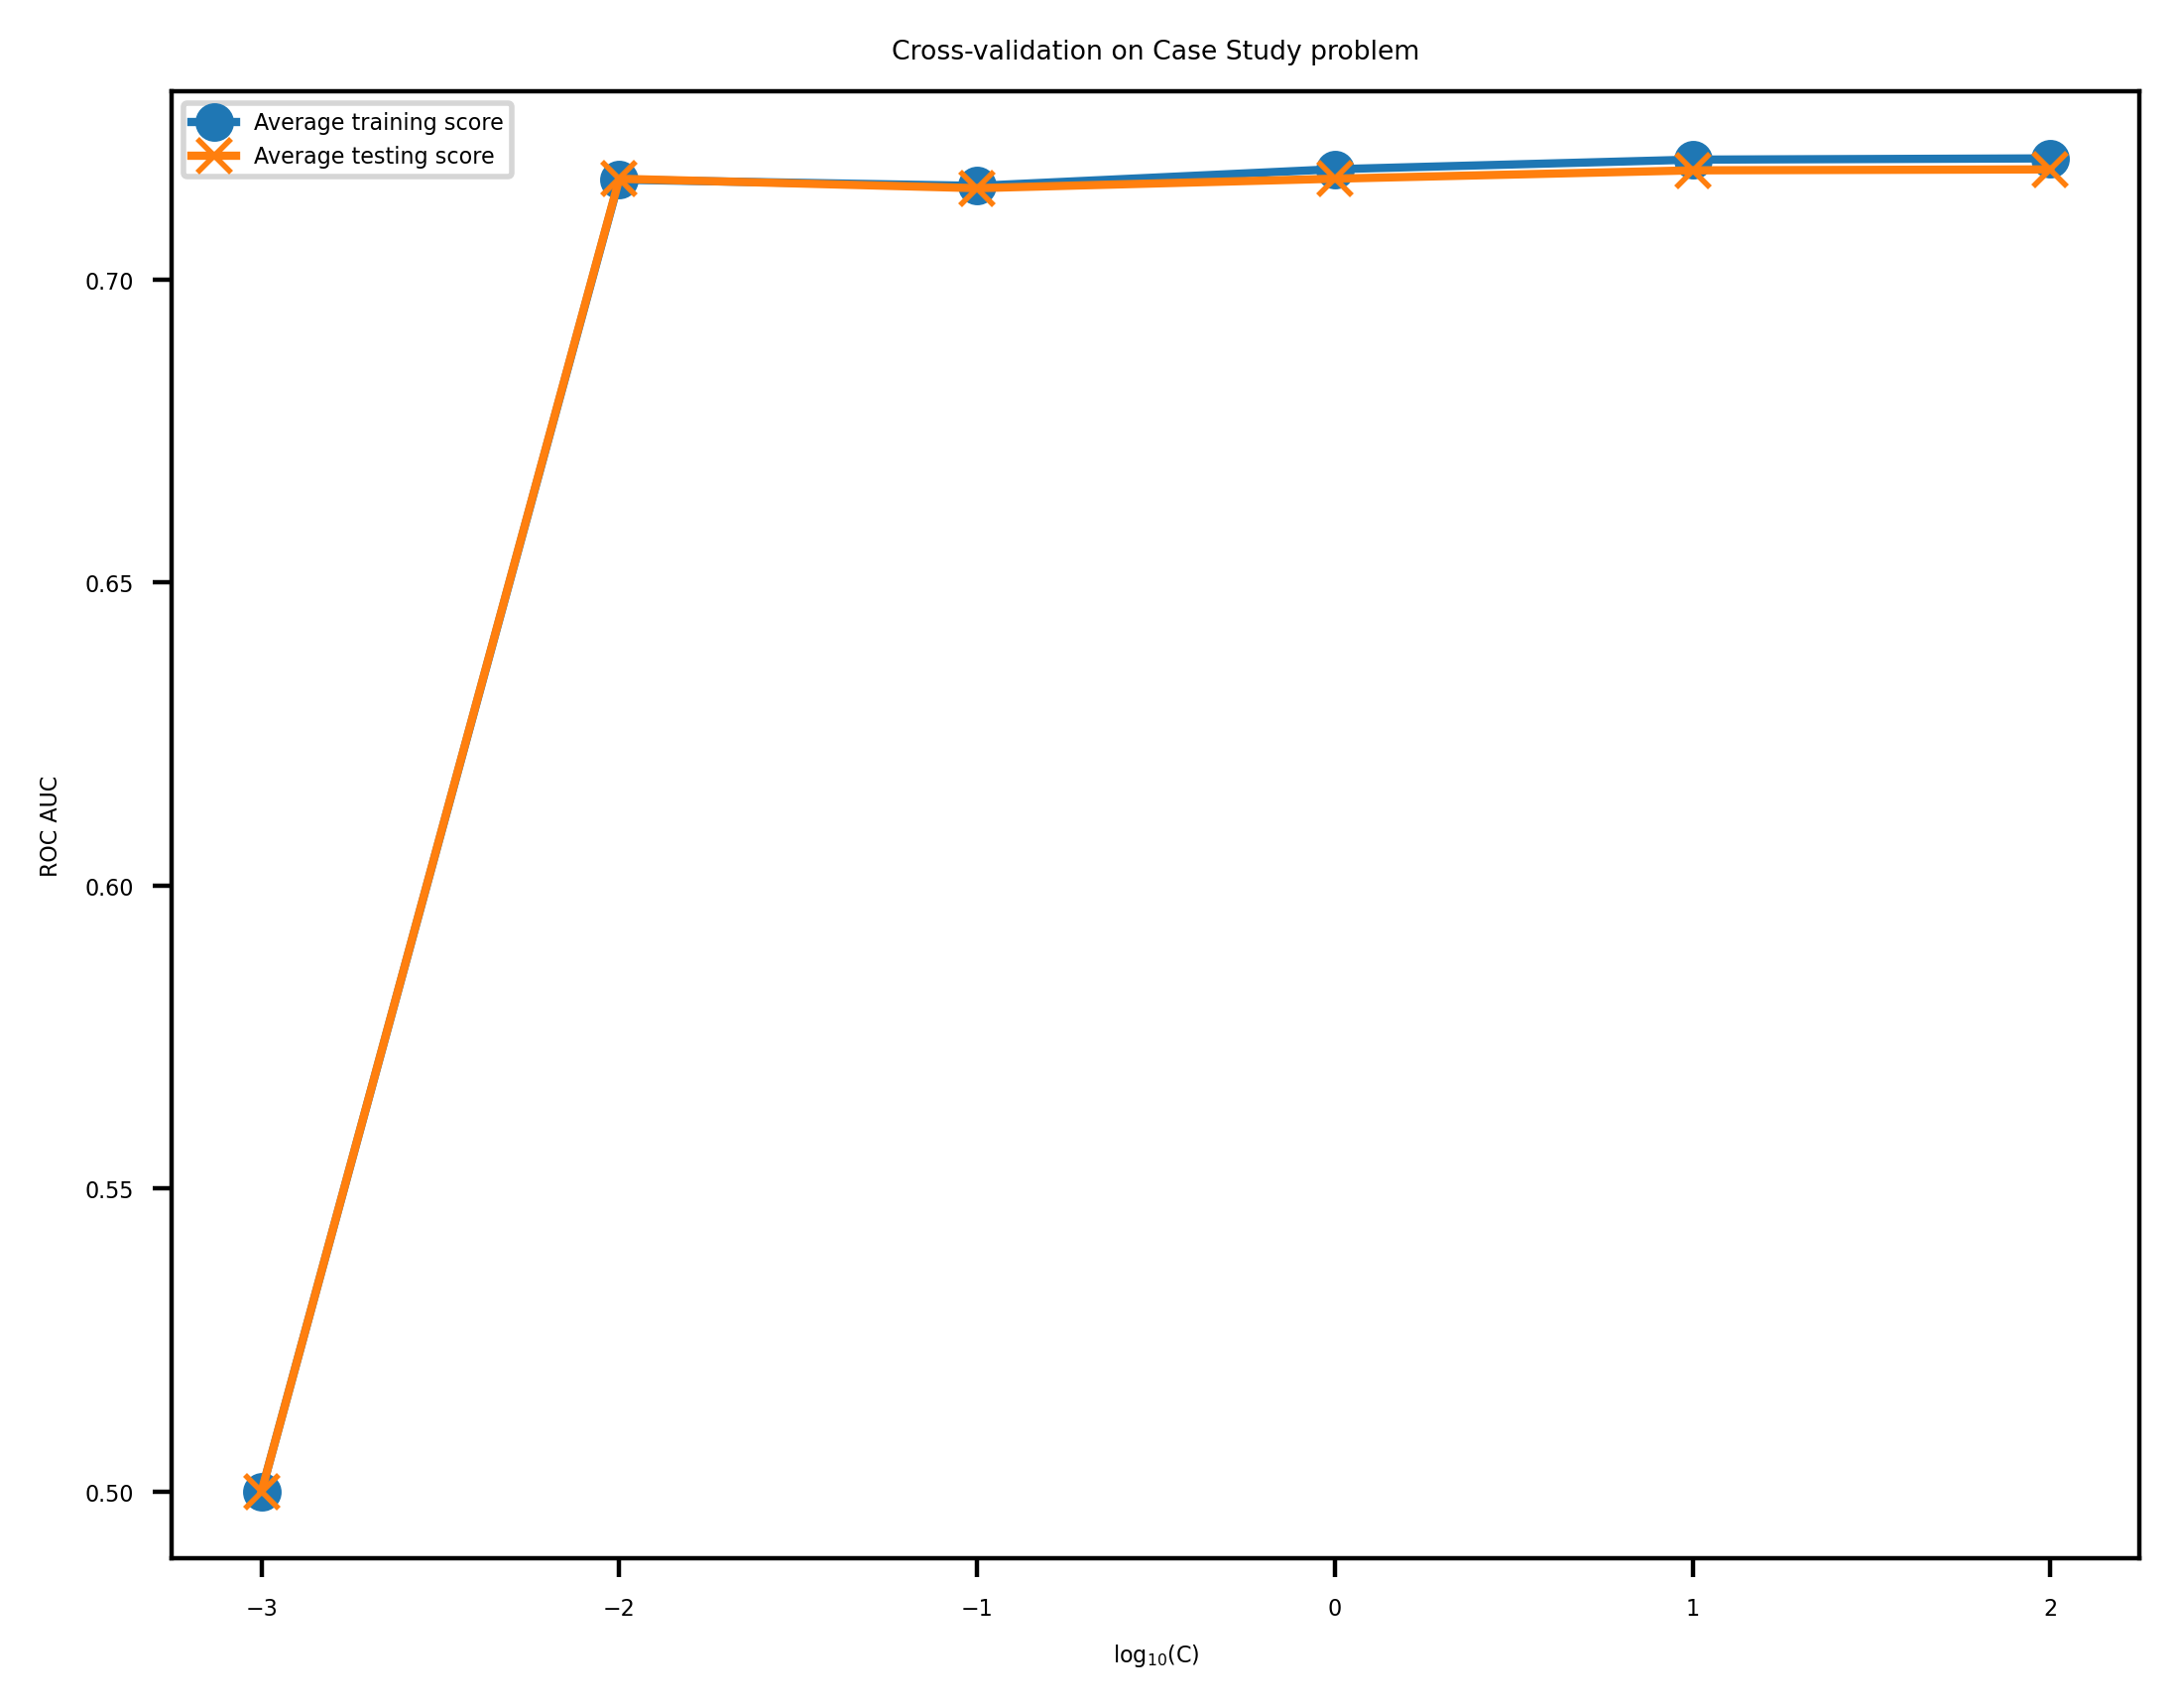

In [31]:
plt.plot(C_val_exponents, np.mean(cv_train_roc_auc, axis=0),
         '-o', label='Average training score')
plt.plot(C_val_exponents, np.mean(cv_test_roc_auc, axis=0),
         '-x', label='Average testing score')
plt.ylabel('ROC AUC')
plt.xlabel('log$_{10}$(C)')
plt.legend()
plt.title('Cross-validation on Case Study problem')

regularization does not impart much benefit here, as may
be expected: for lower C values, which correspond to stronger regularization,
model testing (as well as training) performance decreases. While we are able to
increase model performance over our previous efforts by using all the features
available, it appears there is no overfitting going on. Instead, the training and
test scores are about the same. Instead of overfitting, it's possible that we may
be underfitting. 

Let's try engineering some interaction features to see if they can
improve performance.

In [32]:
from sklearn.preprocessing import PolynomialFeatures

In [33]:
make_interactions = PolynomialFeatures(degree=2,interaction_only=True,include_bias=False)

# interaction_only=False ：x_1, x_2, x_1^2, x_2^2, x_1x_2 
# interaction_only=True ：x_1, x_2, x_1x_2 （只有原始特征和它们的乘积，没有平方项）

In [34]:
X_interact = make_interactions.fit_transform(X)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_interact, df['default payment next month'].values,
 test_size=0.2, random_state=24)

In [36]:
print(X_train.shape)
print(X_test.shape)

(21331, 153)
(5333, 153)


In [37]:
%%time
cv_train_roc_auc, cv_test_roc_auc, cv_test_roc = \
cross_val_C_search_pipe(k_folds, C_vals, scale_lr_pipeline, X_train, y_train)

/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done with C = 100.0


/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done with C = 10.0


/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done with C = 1.0
Done with C = 0.1
Done with C = 0.01
Done with C = 0.001
CPU times: user 3min 41s, sys: 5.98 s, total: 3min 47s
Wall time: 3min 12s


Text(0.5, 1.0, 'Cross-validation on Case Study problem')

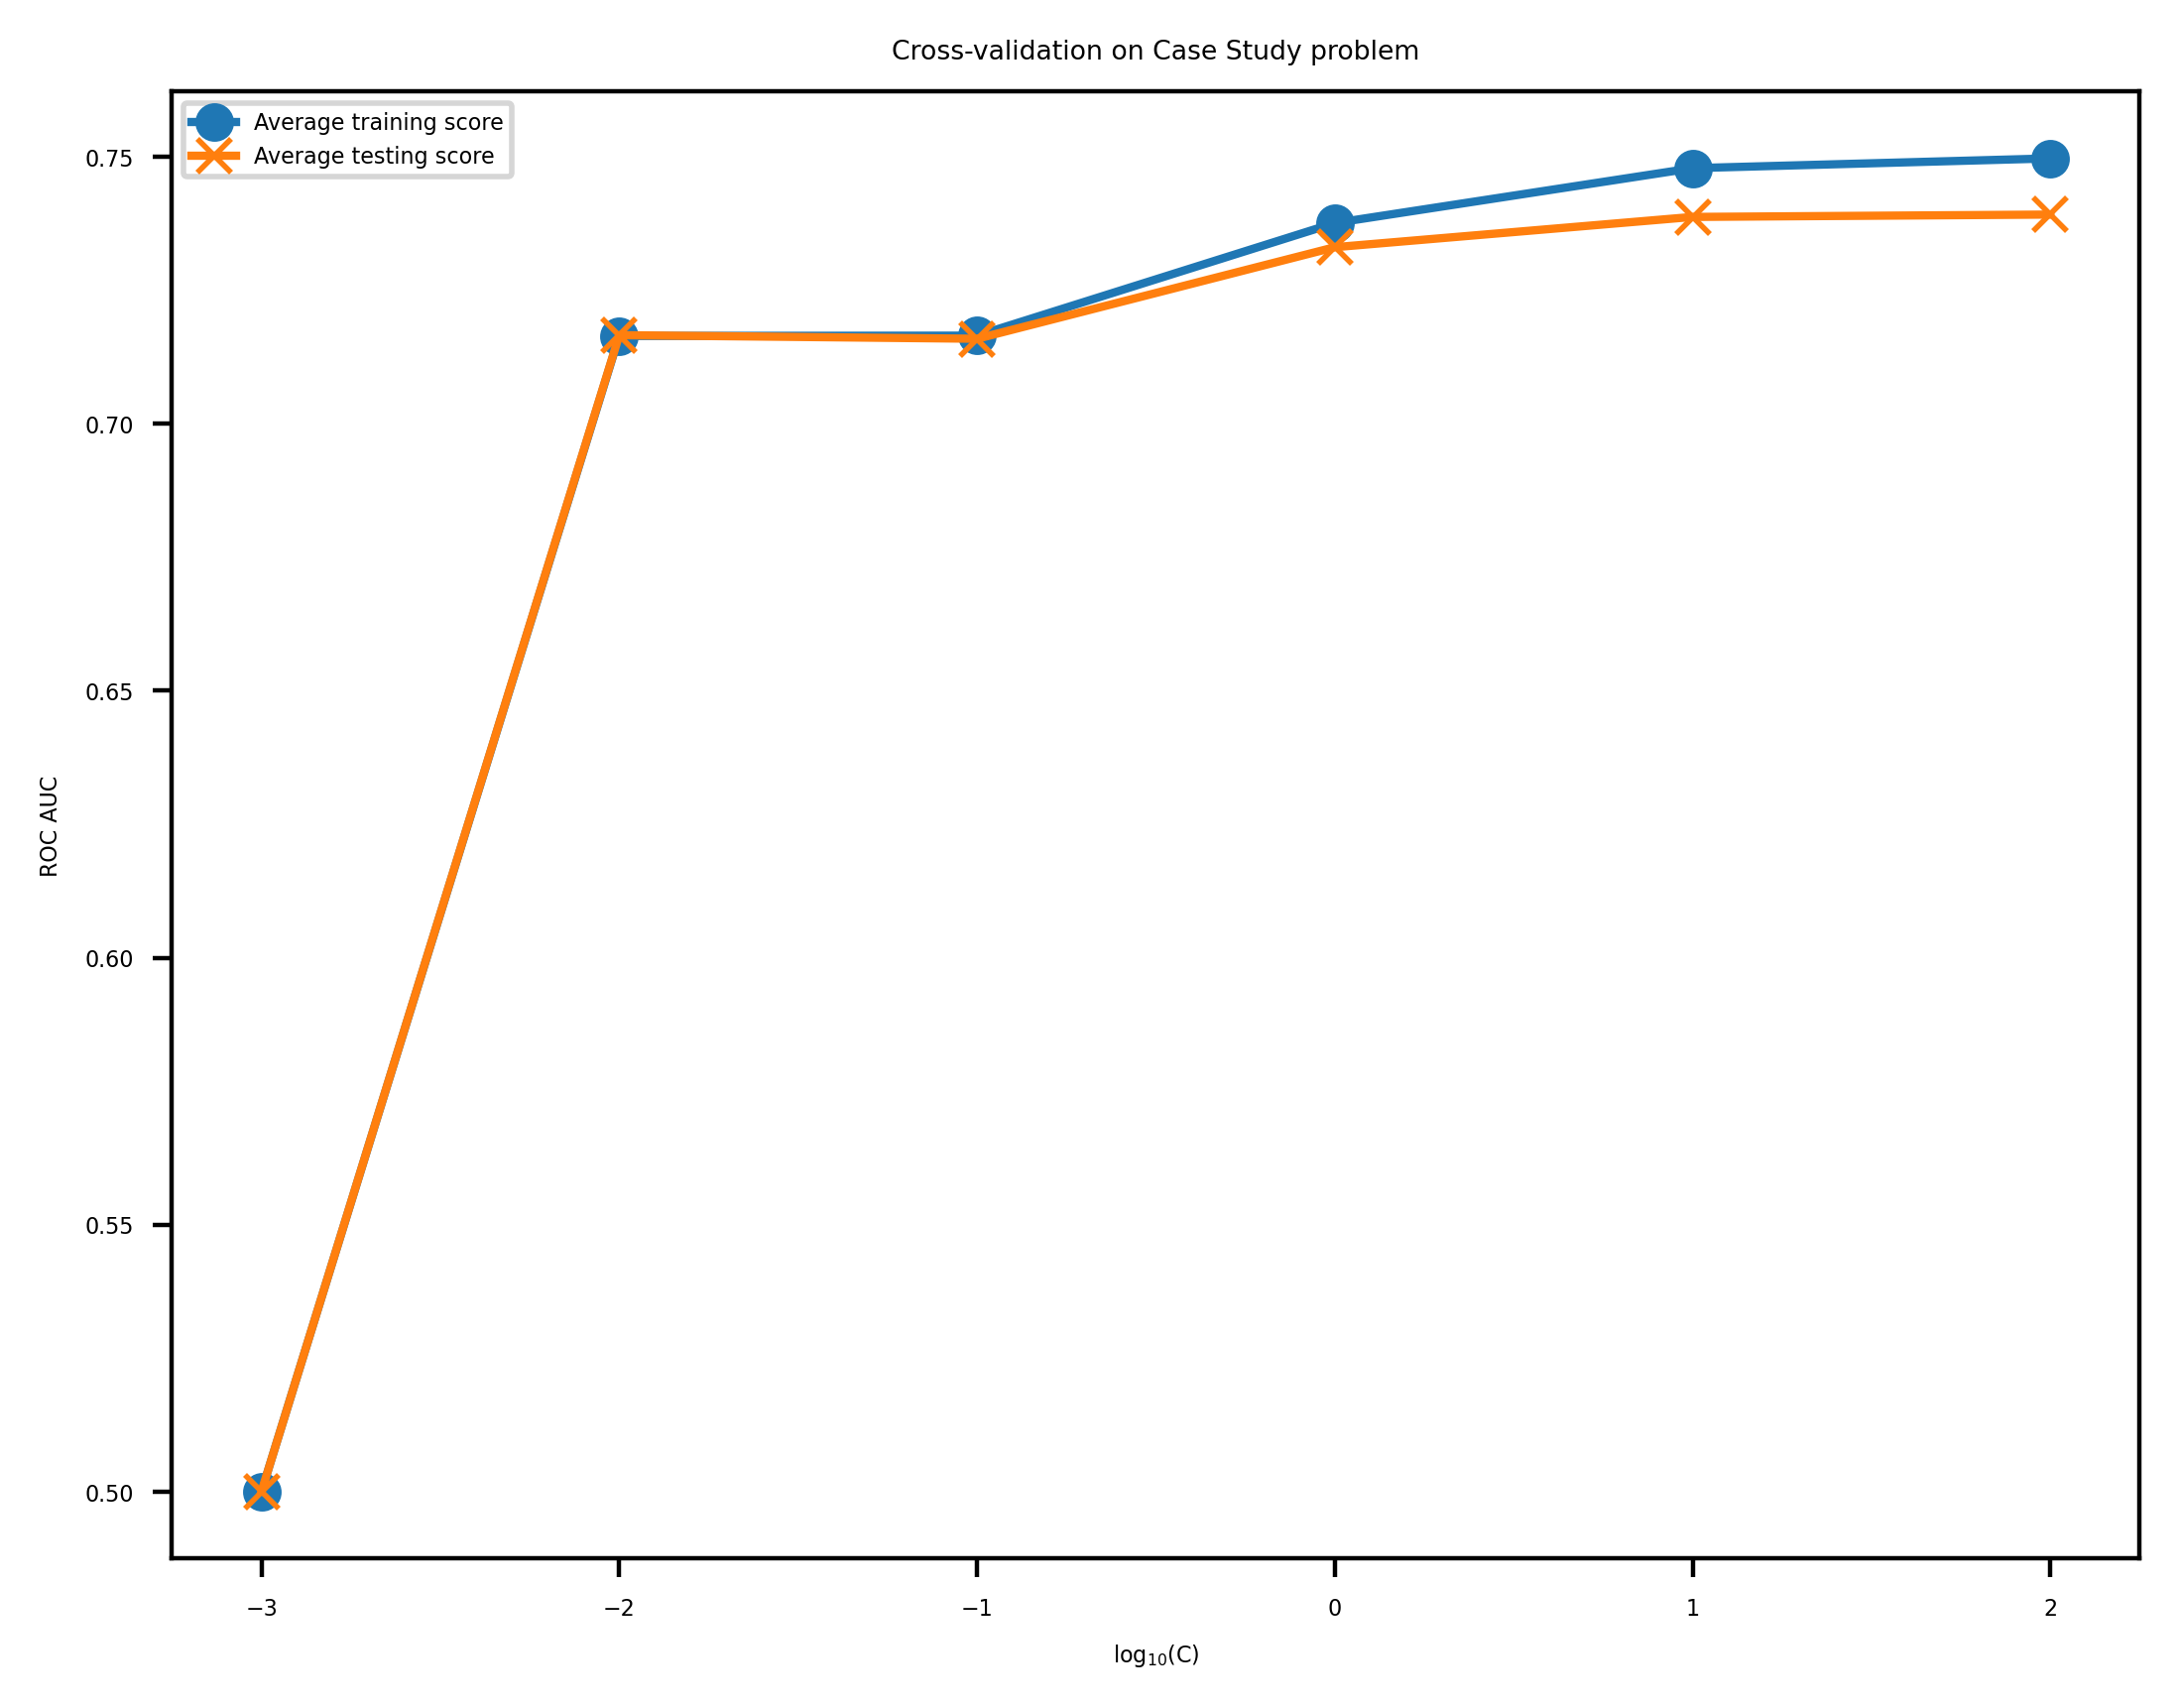

In [38]:
plt.plot(C_val_exponents, np.mean(cv_train_roc_auc, axis=0), '-o',
        label='Average training score')
plt.plot(C_val_exponents, np.mean(cv_test_roc_auc, axis=0), '-x',
        label='Average testing score')
plt.ylabel('ROC AUC')
plt.xlabel('log$_{10}$(C)')
plt.legend()
plt.title('Cross-validation on Case Study problem')

In [39]:
np.mean(cv_test_roc_auc, axis=0)

array([0.73920744, 0.73876379, 0.73309543, 0.71594092, 0.71661792,
       0.5       ])

Engineering the interaction features increases the best model test score to about
ROC AUC = 0.74 on average across the folds, from about 0.72 without including
interactions. These scores happen at C = 100, that is, with negligible regularization.
On the plot of training versus test scores for the model with interactions, you can see
that the training score is a bit higher than the test score, so it could be said that some
amount of overfitting is going on. However, we cannot increase the test score through
regularization here, so this may not be a problematic instance of overfitting. In most
cases, whatever strategy yields the highest test score is the best strategy.

In summary, adding interaction features improved cross-validation performance, and
regularization appears not to be useful for the case study at this point, using a logistic
regression model. We will reserve the step of fitting on all the training data for later
when we've tried other models in cross-validation to find the best model.